**kalın metin**# 01  EDA & ML Baseline
## Fraud Detection via Graph Theory | Graduate Graph Theory Course

**Research Hypothesis:**
> Fraudulent entities form structurally distinct communities in transaction graphs.
> Graph-theoretic methods significantly outperform tabular anomaly detection
> on relational fraud data especially for Medicare provider-level fraud.

**Drive structure required:**
```
MyDrive/fraudDataset/
  creditcard / creditcard.csv
  leie       / UPDATED.csv
  medicare   / Medicare_Part_D_...2017.csv
  medicare   / Medicare_Part_D_...2018.csv
  medicare   / Medicare_Part_D_...2019.csv
  Fraud-Detection-GT / (this project)
```


In [1]:
# ============================================================
# Google Colab Setup -- Run this cell FIRST every session
# ============================================================
import os, sys, glob

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ── Roots ────────────────────────────────────────────────────
DRIVE_ROOT   = "/content/drive/MyDrive/fraudDataset"
PROJECT_ROOT = f"{DRIVE_ROOT}/Fraud-Detection-GT"

# Add project src/ to Python path so we can import from src/
sys.path.insert(0, PROJECT_ROOT)

# ── Dataset Paths ─────────────────────────────────────────────
CC_PATH  = f"{DRIVE_ROOT}/creditcard/creditcard.csv"
LEIE_PATH = f"{DRIVE_ROOT}/leie/UPDATED.csv"

# Medicare: 3 separate yearly files (auto-detect names)
MED_DIR = f"{DRIVE_ROOT}/medicare"
MED_FILES = sorted(glob.glob(f"{MED_DIR}/*.csv"))  # finds all CSVs

# ── Output Paths (on Drive  →  survive session restarts) ─────
OUTPUTS_DIR = f"{PROJECT_ROOT}/outputs"
FIGURES_DIR = f"{PROJECT_ROOT}/outputs/figures"
METRICS_DIR = f"{PROJECT_ROOT}/outputs/metrics"
MODELS_DIR  = f"{PROJECT_ROOT}/outputs/models"
GRAPHS_DIR  = f"{PROJECT_ROOT}/data/graphs"

# ML baseline pickles (optional -- upload Fraud-Detection project too)
ML_PICKLES_DIR = f"{DRIVE_ROOT}/Fraud-Detection/pickled_storage"

# Create output directories (idempotent)
for _d in [OUTPUTS_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR, GRAPHS_DIR,
           f"{GRAPHS_DIR}/credit_card", f"{GRAPHS_DIR}/medicare"]:
    os.makedirs(_d, exist_ok=True)

# Load config.yaml
import yaml
_cfg_path = f"{PROJECT_ROOT}/config.yaml"
CONFIG = {}
if os.path.exists(_cfg_path):
    with open(_cfg_path) as _f:
        CONFIG = yaml.safe_load(_f)

# ── Status Report ─────────────────────────────────────────────
print("=" * 58)
print("  Fraud Detection GT  |  Colab + Drive Environment")
print("=" * 58)
print(f"  Project Root  : {PROJECT_ROOT}")
print(f"  Credit Card   : {CC_PATH}")
print(f"  LEIE file     : {LEIE_PATH}")
print(f"  Medicare files: {len(MED_FILES)} found in {MED_DIR}")
for _f in MED_FILES:
    print(f"    - {os.path.basename(_f)}")
print()
print(f"  Outputs       : {OUTPUTS_DIR}")
print()

# Verify
_ok = True
for _path, _label in [(CC_PATH, "creditcard/creditcard.csv"),
                       (LEIE_PATH, "leie/UPDATED.csv")]:
    if os.path.exists(_path):
        _mb = os.path.getsize(_path)/1e6
        print(f"  [OK]  {_label} ({_mb:.0f} MB)")
    else:
        print(f"  [!!]  {_label} NOT FOUND")
        _ok = False

if len(MED_FILES) == 0:
    print("  [!!]  No Medicare CSVs found in medicare/")
    _ok = False
elif len(MED_FILES) < 3:
    print(f"  [??]  Only {len(MED_FILES)} Medicare file(s) found (expected 3)")
else:
    total_mb = sum(os.path.getsize(f)/1e6 for f in MED_FILES)
    print(f"  [OK]  medicare/ ({len(MED_FILES)} files, {total_mb:.0f} MB total)")

print()
print("  Ready!" if _ok else "  WARNING: Some files missing -- check Drive paths above")
print("=" * 58)


Mounted at /content/drive
  Fraud Detection GT  |  Colab + Drive Environment
  Project Root  : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT
  Credit Card   : /content/drive/MyDrive/fraudDataset/creditcard/creditcard.csv
  LEIE file     : /content/drive/MyDrive/fraudDataset/leie/UPDATED.csv
  Medicare files: 3 found in /content/drive/MyDrive/fraudDataset/medicare
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2017.csv
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2018.csv
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2019.csv

  Outputs       : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT/outputs

  [OK]  creditcard/creditcard.csv (151 MB)
  [OK]  leie/UPDATED.csv (15 MB)
  [OK]  medicare/ (3 files, 11921 MB total)

  Ready!


In [2]:
# ============================================================
# Install required packages (once per Colab session)
# ============================================================
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + list(pkgs))

print("Installing packages...")
_pip("networkx", "python-louvain", "pyvis", "pyyaml", "plotly", "tqdm")

# PyTorch Geometric -- auto-detect CUDA
import torch
_cuda = torch.version.cuda
if _cuda:
    _cu  = "cu" + _cuda.replace(".", "")
    _tv  = torch.__version__.split("+")[0]
    _url = f"https://data.pyg.org/whl/torch-{_tv}+{_cu}.html"
    print(f"CUDA {_cuda} detected -- installing PyG GPU build")
    _pip("torch-geometric")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "torch-scatter", "torch-sparse", "-f", _url])
else:
    print("No CUDA -- installing PyG CPU build")
    _pip("torch-geometric")

print("All packages installed successfully!")


Installing packages...
CUDA 12.8 detected -- installing PyG GPU build
All packages installed successfully!


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib, seaborn as sns, warnings, json
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.facecolor':'#0F0F1A', 'axes.facecolor':'#1A1A2E',
    'text.color':'#EEEEFF', 'axes.labelcolor':'#CCCCEE',
    'xtick.color':'#CCCCEE', 'ytick.color':'#CCCCEE',
})
from src.baseline_loader import HARDCODED_BASELINE
from src.evaluation import get_ml_baseline_table
print("Libraries loaded OK")


Libraries loaded OK


---
## 1. Credit Card Fraud Dataset
- 284,807 transactions | 492 fraud (0.172%)
- 28 PCA features + Amount + Time


In [4]:
try:
    df_cc = pd.read_csv(CC_PATH)
    print(f"Loaded: {df_cc.shape} | Fraud: {df_cc['Class'].sum()} ({df_cc['Class'].mean()*100:.3f}%)")
except FileNotFoundError:
    print("creditcard.csv not found -- using synthetic demo")
    np.random.seed(42); n=5000
    df_cc = pd.DataFrame(np.random.randn(n,28), columns=[f'V{i}' for i in range(1,29)])
    df_cc['Amount']=(np.abs(np.random.exponential(100,n)))
    df_cc['Time']=np.arange(n)
    df_cc['Class']=(np.random.rand(n)<0.002).astype(int)
df_cc.head(3)


Loaded: (284807, 31) | Fraud: 492 (0.173%)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


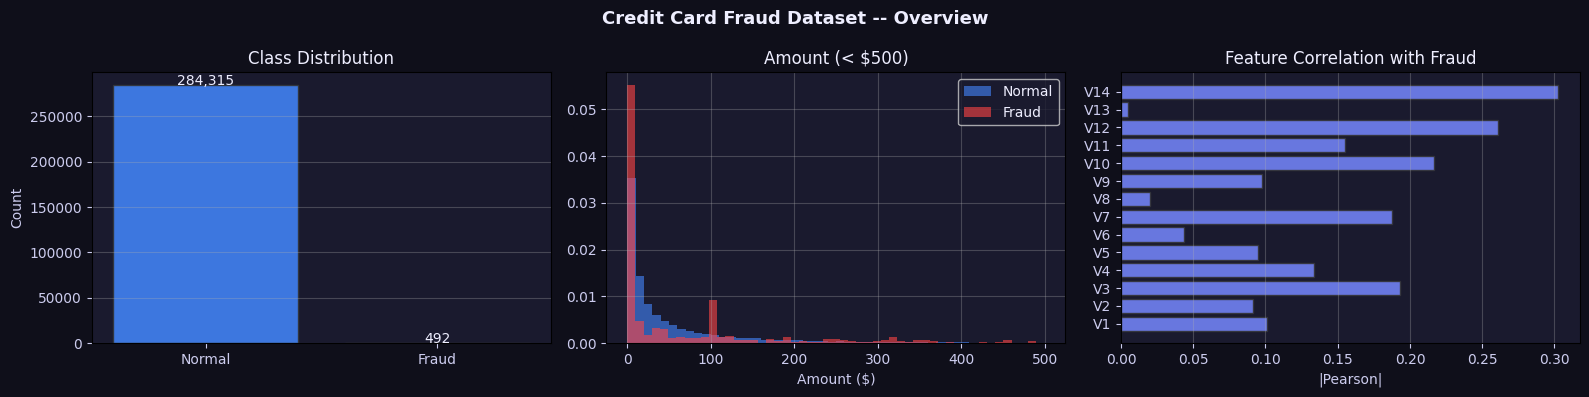

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Credit Card Fraud Dataset -- Overview', fontsize=13, color='#EEEEFF', fontweight='bold')

ax = axes[0]
counts = df_cc['Class'].value_counts()
b = ax.bar(['Normal','Fraud'], counts.values, color=['#4488FF','#FF4444'], alpha=0.85, edgecolor='#333')
ax.set_title('Class Distribution'); ax.set_ylabel('Count'); ax.grid(True, axis='y', alpha=0.3)
for bar,v in zip(b,counts.values): ax.text(bar.get_x()+bar.get_width()/2, v+200, f'{v:,}', ha='center')

ax = axes[1]
for cls,col,lbl in [(0,'#4488FF','Normal'),(1,'#FF4444','Fraud')]:
    d=df_cc[df_cc['Class']==cls]['Amount']; ax.hist(d[d<500],bins=50,alpha=0.6,color=col,label=lbl,density=True)
ax.set_title('Amount (< $500)'); ax.set_xlabel('Amount ($)'); ax.legend(); ax.grid(True,alpha=0.3)

ax = axes[2]
fcols=[f'V{i}' for i in range(1,15)]
ax.barh(fcols,[abs(df_cc[c].corr(df_cc['Class'])) for c in fcols],color='#7788FF',alpha=0.85,edgecolor='#333')
ax.set_title('Feature Correlation with Fraud'); ax.set_xlabel('|Pearson|'); ax.grid(True,axis='x',alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/cc_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 2. Medicare + LEIE Datasets

**Medicare Part D (CMS):** Provider-level prescription data 2017-2019 (3 files)
**LEIE (OIG):** Excluded providers list -- our fraud ground truth

**Join logic:** If a provider's NPI appears in LEIE -> label = 1 (fraud)


In [6]:
import glob, os

# Load Medicare (sample 100k rows from each file to avoid memory issues in EDA)
print(f"Medicare files found: {len(MED_FILES)}")
for f in MED_FILES: print(f"  {os.path.basename(f)}")

med_dfs = []
for fp in MED_FILES:
    yr = next((y for y in ['2017','2018','2019'] if y in fp), None)
    df_tmp = pd.read_csv(fp, nrows=100000, low_memory=False)
    if yr: df_tmp['year'] = yr
    med_dfs.append(df_tmp)
    print(f"  Loaded {os.path.basename(fp)}: {df_tmp.shape}")

df_med_sample = pd.concat(med_dfs, ignore_index=True)
print(f"\nCombined sample: {df_med_sample.shape}")
print(f"Columns: {df_med_sample.columns.tolist()[:15]}...")


Medicare files found: 3
  Medicare_Part_D_Prescribers_by_Provider_and_Drug_2017.csv
  Medicare_Part_D_Prescribers_by_Provider_and_Drug_2018.csv
  Medicare_Part_D_Prescribers_by_Provider_and_Drug_2019.csv
  Loaded Medicare_Part_D_Prescribers_by_Provider_and_Drug_2017.csv: (100000, 23)
  Loaded Medicare_Part_D_Prescribers_by_Provider_and_Drug_2018.csv: (100000, 23)
  Loaded Medicare_Part_D_Prescribers_by_Provider_and_Drug_2019.csv: (100000, 23)

Combined sample: (300000, 23)
Columns: ['Prscrbr_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_State_FIPS', 'Prscrbr_Type', 'Prscrbr_Type_Src', 'Brnd_Name', 'Gnrc_Name', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst', 'Tot_Benes']...


In [7]:
# Load LEIE
print(f"Loading LEIE from: {LEIE_PATH}")
leie_df = pd.read_csv(LEIE_PATH, low_memory=False)
print(f"LEIE shape: {leie_df.shape}")
print(f"LEIE columns: {leie_df.columns.tolist()}")

# Find NPI column
leie_npi_col = next((c for c in leie_df.columns if 'NPI' in c.upper() or 'npi' in c.lower()), None)
print(f"\nNPI column: {leie_npi_col}")

if leie_npi_col:
    valid_npis = leie_df[leie_npi_col].astype(str).str.strip()
    valid_npis = set(n for n in valid_npis if n.isdigit() and len(n)==10 and n!='0000000000')
    print(f"Valid 10-digit NPIs in LEIE: {len(valid_npis):,}")


Loading LEIE from: /content/drive/MyDrive/fraudDataset/leie/UPDATED.csv
LEIE shape: (82749, 18)
LEIE columns: ['LASTNAME', 'FIRSTNAME', 'MIDNAME', 'BUSNAME', 'GENERAL', 'SPECIALTY', 'UPIN', 'NPI', 'DOB', 'ADDRESS', 'CITY', 'STATE', 'ZIP', 'EXCLTYPE', 'EXCLDATE', 'REINDATE', 'WAIVERDATE', 'WVRSTATE']

NPI column: NPI
Valid 10-digit NPIs in LEIE: 8,306


In [8]:
# Medicare NPI column detection
npi_candidates = ['Prscrbr_NPI','prscrbr_npi','NPI','npi']
drug_candidates = ['Gnrc_Name','gnrc_name','Brnd_Name','brnd_name']

npi_col_med  = next((c for c in df_med_sample.columns if c.lower() in [x.lower() for x in npi_candidates]), None)
drug_col_med = next((c for c in df_med_sample.columns if c.lower() in [x.lower() for x in drug_candidates]), None)
state_col_med = next((c for c in df_med_sample.columns
                       if 'state' in c.lower() and 'abrvtn' in c.lower()), None)
claims_col_med = next((c for c in df_med_sample.columns if 'clm' in c.lower()), None)

print(f"NPI col:    {npi_col_med}")
print(f"Drug col:   {drug_col_med}")
print(f"State col:  {state_col_med}")
print(f"Claims col: {claims_col_med}")

if npi_col_med and leie_npi_col:
    df_med_sample['_npi_str'] = df_med_sample[npi_col_med].astype(str).str.strip()
    df_med_sample['fraud_label'] = df_med_sample['_npi_str'].isin(valid_npis).astype(int)
    fraud_rate = df_med_sample.drop_duplicates(npi_col_med)['fraud_label'].mean()
    print(f"\nFraud rate (unique providers): {fraud_rate*100:.3f}%")
    print(f"Fraud providers in sample: {df_med_sample.drop_duplicates(npi_col_med)['fraud_label'].sum():,}")


NPI col:    Prscrbr_NPI
Drug col:   Brnd_Name
State col:  Prscrbr_State_Abrvtn
Claims col: Tot_Clms

Fraud rate (unique providers): 0.094%
Fraud providers in sample: 6


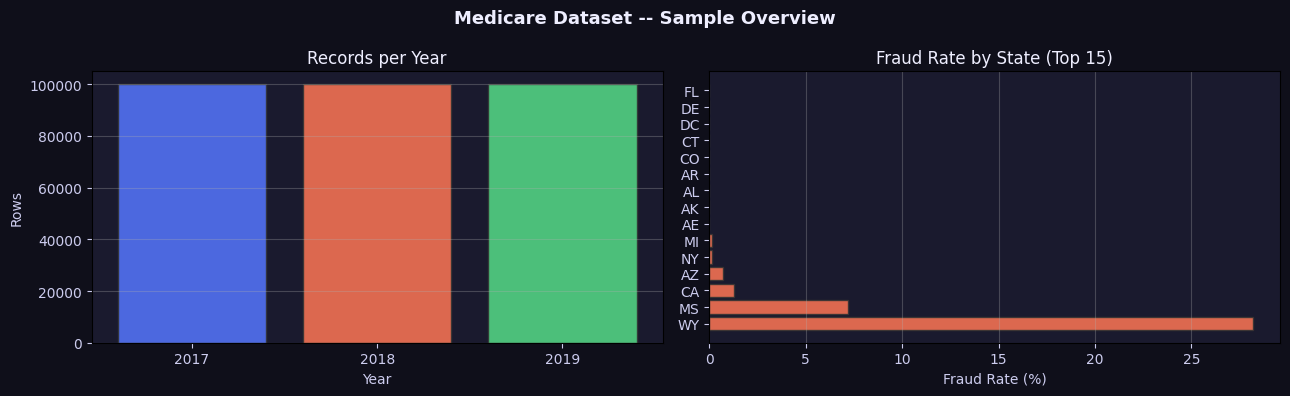

In [9]:
# Medicare EDA plots
if npi_col_med and drug_col_med:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Medicare Dataset -- Sample Overview', fontsize=13, color='#EEEEFF', fontweight='bold')

    # Year distribution
    ax = axes[0]
    if 'year' in df_med_sample.columns:
        vc = df_med_sample['year'].value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color=['#5577FF','#FF7755','#55DD88'], alpha=0.85, edgecolor='#333')
        ax.set_xlabel('Year'); ax.set_ylabel('Rows'); ax.set_title('Records per Year')
        ax.grid(True, axis='y', alpha=0.3)

    # State fraud rate (if available)
    ax = axes[1]
    if state_col_med and 'fraud_label' in df_med_sample.columns:
        by_state = (df_med_sample.groupby(state_col_med)['fraud_label']
                    .mean().nlargest(15)*100)
        ax.barh(by_state.index, by_state.values, color='#FF7755', alpha=0.85, edgecolor='#333')
        ax.set_xlabel('Fraud Rate (%)'); ax.set_title('Fraud Rate by State (Top 15)')
        ax.grid(True, axis='x', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'State/label data not available',
                ha='center', va='center', transform=ax.transAxes, color='#EEEEFF')

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/medicare_eda_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Could not identify required columns for EDA plots")


---
## 3. ML Baseline (from BLG607 Companion Project)

| Dataset | Best Model | AUC-ROC | Note |
|---------|-----------|---------|------|
| Credit Card | GMM | **0.959** | High â€” less relational |
| Medicare | IsoForest | **0.608** | Near-random â€” graph should dominate |


In [10]:
try:
    ml_df = get_ml_baseline_table(ML_PICKLES_DIR)
    print("ML results loaded from Drive")
except Exception:
    print("Using hardcoded baseline (pickles not on Drive)")
    recs = []
    for ds, methods in HARDCODED_BASELINE.items():
        for m, v in methods.items():
            recs.append({'Dataset':ds,'Method':m,'AUC_ROC':v['AUC_ROC'],
                         'AUC_PRC':v['AUC_PRC'],'Category':'Tabular-ML'})
    ml_df = pd.DataFrame(recs)

print(ml_df.to_string(index=False))


ML results loaded from Drive
    Dataset     Source          Method  Mean_AUC  Mean_AUPRC
Credit Card Tabular-ML           OCSVM    0.9514      0.2731
Credit Card Tabular-ML             GMM    0.9588      0.5720
Credit Card Tabular-ML IsolationForest    0.9496      0.1543
Credit Card Tabular-ML             LOF    0.9532      0.6391
Credit Card Tabular-ML   Ensemble_Best    0.9535      0.5191
   Medicare Tabular-ML           OCSVM    0.5261      0.0019
   Medicare Tabular-ML             GMM    0.5977      0.0023
   Medicare Tabular-ML IsolationForest    0.6081      0.0038
   Medicare Tabular-ML             LOF    0.6043      0.0021
   Medicare Tabular-ML   Ensemble_Best    0.5974      0.0037


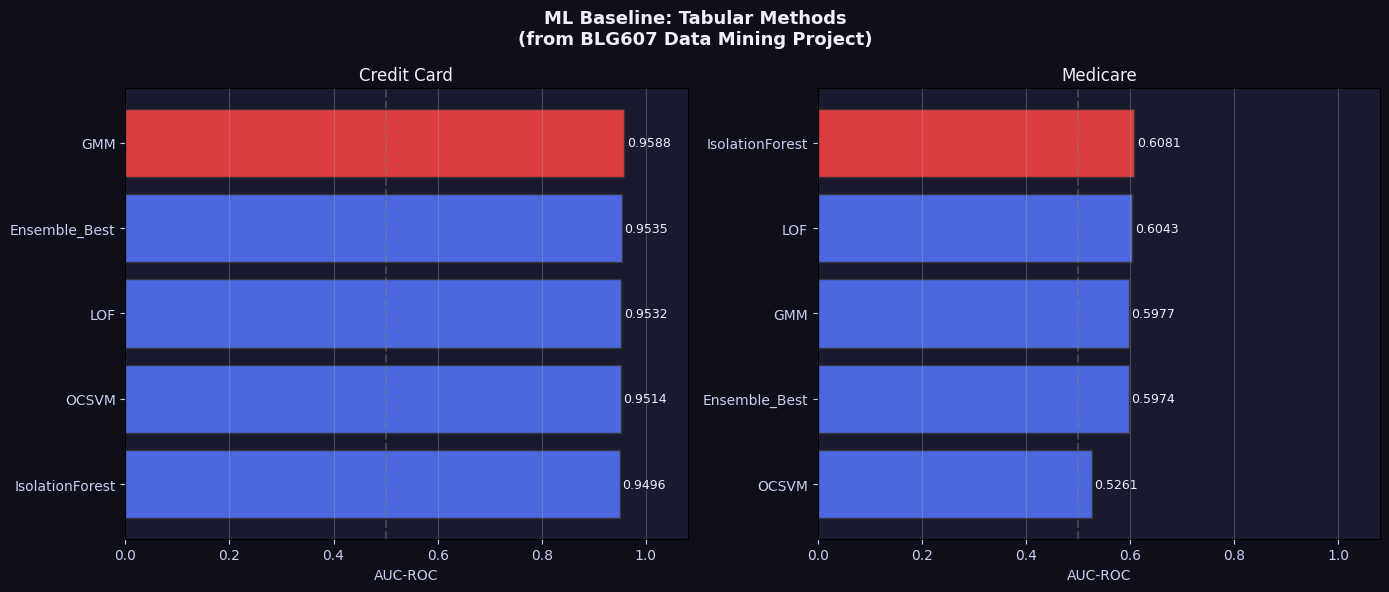

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ML Baseline: Tabular Methods\n(from BLG607 Data Mining Project)',
              fontsize=13, color='#EEEEFF', fontweight='bold')

# Normalize column name: handle both 'AUC_ROC' and 'Mean_AUC'
def get_auc_col(df):
    for c in ['AUC_ROC', 'Mean_AUC', 'auc_roc']:
        if c in df.columns:
            return c
    return None

for ax, (ds, kw) in zip(axes, [('Credit Card','Credit'),('Medicare','Medicare')]):
    sub = ml_df[ml_df['Dataset'].str.contains(kw, case=False, na=False)].copy()
    auc_col = get_auc_col(sub)

    # Fallback to hardcoded if empty or no AUC column
    if len(sub) == 0 or auc_col is None:
        sub = pd.DataFrame(
            [{'Method': m, 'AUC_ROC': v['AUC_ROC']}
             for m, v in HARDCODED_BASELINE[ds].items()])
        auc_col = 'AUC_ROC'
    else:
        # Rename to standard for consistency
        sub = sub.rename(columns={auc_col: 'AUC_ROC'})
        auc_col = 'AUC_ROC'

    aucs    = sub[auc_col].values.astype(float)
    methods = sub['Method'].values
    si      = np.argsort(aucs)

    bars = ax.barh(methods[si], aucs[si],
                   color=['#FF4444' if a == max(aucs) else '#5577FF' for a in aucs[si]],
                   alpha=0.85, edgecolor='#333')
    ax.set_xlim(0, 1.08); ax.set_xlabel('AUC-ROC'); ax.set_title(ds)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.4)
    for bar, v in zip(bars, aucs[si]):
        ax.text(v+0.005, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9, color='#EEEEFF')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ml_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
stats = {
    'cc_n_rows': int(len(df_cc)), 'cc_fraud': int(df_cc['Class'].sum()),
    'cc_fraud_rate': float(df_cc['Class'].mean()),
    'ml_best_cc_auc': 0.9588, 'ml_best_med_auc': 0.6081,
}
with open(f'{METRICS_DIR}/dataset_stats.json','w') as f: json.dump(stats,f,indent=2)

print("=" * 58)
print("  NOTEBOOK 01 COMPLETE")
print("=" * 58)
print(f"  Credit Card : {stats['cc_n_rows']:,} rows | {stats['cc_fraud']:,} fraud")
print(f"  Medicare    : {len(MED_FILES)} files loaded (sample EDA done)")
print(f"  ML Best AUC : CC={stats['ml_best_cc_auc']} | Med={stats['ml_best_med_auc']}")
print("  Next -> 02_Graph_Construction.ipynb")
print("=" * 58)


  NOTEBOOK 01 COMPLETE
  Credit Card : 284,807 rows | 492 fraud
  Medicare    : 3 files loaded (sample EDA done)
  ML Best AUC : CC=0.9588 | Med=0.6081
  Next -> 02_Graph_Construction.ipynb
